# House Price Prediction using Linear Regression

This project uses the California Housing dataset to build and evaluate a Linear Regression model for predicting house prices.

# Objective

The objective of this project is to build and evaluate a Linear Regression model using the California Housing dataset. The project demonstrates the complete Machine Learning workflow including data loading, preprocessing, visualization, model training, prediction, and evaluation.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [2]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Exploratory Data Analysis

In [4]:
df.shape

(20640, 9)

In [5]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

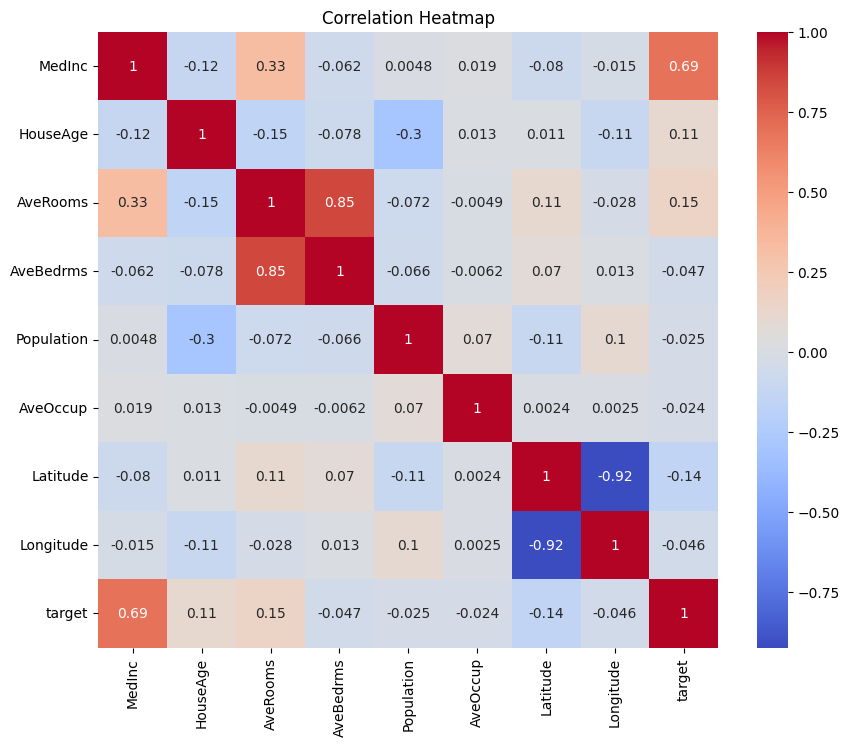

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Feature Selection and Data Splitting

#In this section, the input features and target variable are separated. The dataset is then divided into training and testing sets for model training and evaluation.

## Import Required Library

#The train_test_split function is imported to divide the dataset into training and testing data.

In [13]:
from sklearn.model_selection import train_test_split

## Separating Features and Target Variable

#The input features are stored in X and the target variable (house price) is stored in y.

In [15]:
X = df.drop('target', axis=1)

y = df['target']

## Splitting the Dataset

The dataset is divided into training and testing sets. 
80% of the data is used for training and 20% for testing.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Training and Testing Data Shapes

This shows the dimensions of training and testing datasets.

In [17]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


# Linear Regression Model Training

In this section, a Linear Regression model is created and trained using the training dataset.

In [18]:
from sklearn.linear_model import LinearRegression

## Creating the Model

A Linear Regression model object is created.

In [19]:
model = LinearRegression()

## Training the Model

The model is trained using the training dataset.

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Making Predictions

The trained model predicts house prices using the test dataset.

In [21]:
y_pred = model.predict(X_test)

## Sample Predictions

Comparing actual house prices with predicted house prices.

In [22]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657


## Importing Evaluation Metrics

The required evaluation metrics are imported from scikit-learn.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Calculating Evaluation Metrics

The model performance is evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [24]:
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

print("Root Mean Squared Error (RMSE):", rmse)

print("R² Score:", r2)

Mean Absolute Error (MAE): 0.5332001304956555
Root Mean Squared Error (RMSE): 0.7455813830127763
R² Score: 0.575787706032451


## Result Interpretation

- A lower MAE and RMSE indicate better prediction accuracy.
- The R² Score shows how well the model explains the variance in house prices.
- The Linear Regression model achieved reasonable prediction performance on the California Housing dataset.

# Data Visualization


## Actual vs Predicted Values

This scatter plot compares the actual house prices with the predicted house prices.

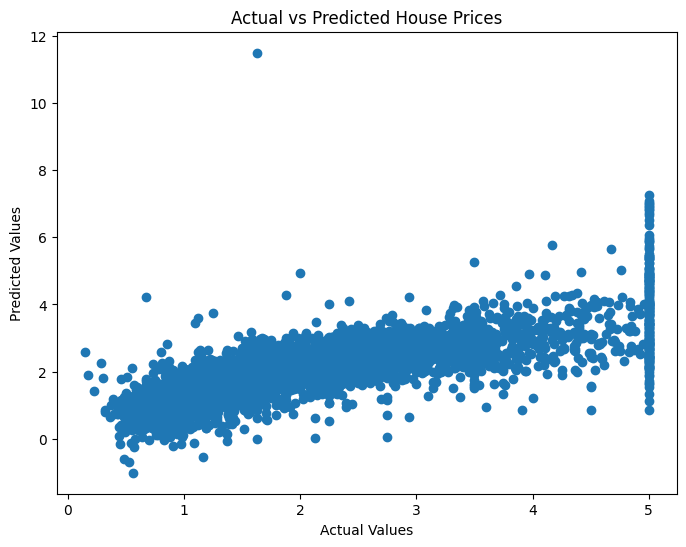

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.show()

## Residual Plot

The residual plot shows the difference between actual and predicted values.

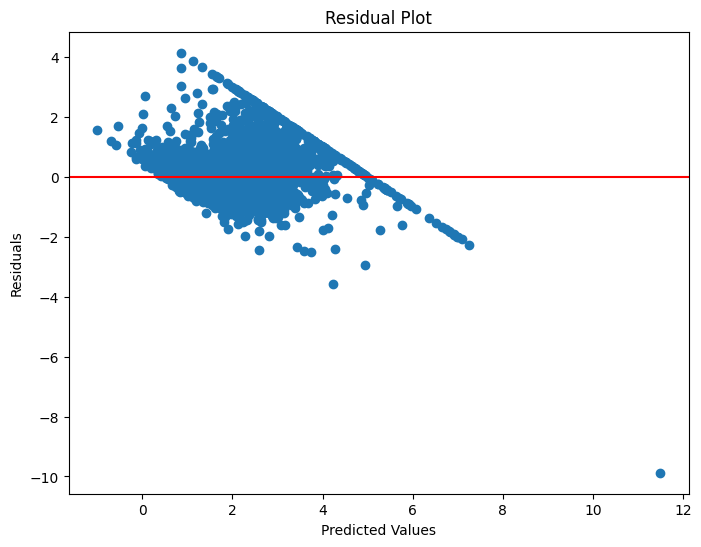

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.axhline(y=0, color='red')

plt.show()

# Conclusion

In this project, a Linear Regression model was successfully built and evaluated using the California Housing dataset.

The workflow included:
- Data loading
- Exploratory Data Analysis (EDA)
- Feature selection
- Data splitting
- Model training
- Prediction and evaluation

The model achieved reasonable prediction performance with an R² Score of approximately 0.57. Visualization techniques such as correlation heatmaps and prediction plots helped in understanding the dataset and model behavior.

This project provided practical exposure to the complete Machine Learning workflow using Python and scikit-learn.

## Saving the Model

The trained Linear Regression model is saved for future use.

In [27]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']